In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

!pip install gdown
!gdown --id 1xY53u4YAJ87sR8JIHk6tqzuaGT7T7NLk
!mkdir -p data/datathon_cleaned_data/
!unzip -o datathon_cleaned_data.zip -d data/datathon_cleaned_data/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xY53u4YAJ87sR8JIHk6tqzuaGT7T7NLk
From (redirected): https://drive.google.com/uc?id=1xY53u4YAJ87sR8JIHk6tqzuaGT7T7NLk&confirm=t&uuid=7d6f1966-d81b-49cb-9700-0950c47b1504
To: /content/datathon_cleaned_data.zip
100% 28.9M/28.9M [00:00<00:00, 46.1MB/s]
Archive:  datathon_cleaned_data.zip
  inflating: data/datathon_cleaned_data/data/cleaned-data/payments.csv  
  inflating: data/datathon_cleaned_data/data/cleaned-data/sales.csv  
  inflating: data/datathon_cleaned_data/data/cleaned-data/promotions.csv  
  inflating: data/datathon_cleaned_data/data/cleaned-data/products.csv  
  inflating: data/datathon_cleaned_data/data/cleaned-data/customers.csv  
  inflating: data/datathon_cleaned_data/data/cleaned-data/invento

In [22]:
sales = pd.read_csv(f"/content/data/datathon_cleaned_data/data/cleaned-data/sales.csv", parse_dates=['Date'])

# **I - FEATURE ENGINEERING**
## **1.1. Feature engineering cho tập train**

In [23]:
import pandas as pd
import numpy as np
from google.colab import files

def engineer_calendar_features(df, date_col='Date'):

    # Tạo bản sao để không làm hỏng dữ liệu gốc, và đảm bảo sắp xếp theo thời gian
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)

In [24]:
# =========================================================================
# A: TÍNH TOÁN BẢNG THỐNG KÊ LỊCH SỬ CHIA THEO THỜI KỲ (REGIME)
# =========================================================================
print("-> Đang phân tách và tính toán Thống kê Lịch sử theo Thời kỳ...")

# Tạo tạm cột cờ thời kỳ và các cột thời gian để groupby
sales_temp = sales.copy()
sales_temp['Date'] = pd.to_datetime(sales_temp['Date'])
sales_temp['Year'] = sales_temp['Date'].dt.year
sales_temp['Month'] = sales_temp['Date'].dt.month
sales_temp['Day_of_week'] = sales_temp['Date'].dt.dayofweek
sales_temp['Is_Post_2019'] = (sales_temp['Year'] >= 2019).astype(int)

# 1. Bảng thống kê theo Tháng & Thời kỳ
monthly_stats = sales_temp.groupby(['Is_Post_2019', 'Month'])['Revenue'].agg(
    Hist_Month_Mean='mean',
    Hist_Month_Std='std'
).reset_index()

# 2. Bảng thống kê theo Thứ trong tuần & Thời kỳ
dow_stats = sales_temp.groupby(['Is_Post_2019', 'Day_of_week'])['Revenue'].agg(
    Hist_DoW_Mean='mean'
).reset_index()

-> Đang phân tách và tính toán Thống kê Lịch sử theo Thời kỳ...


In [25]:
# =========================================================================
# B: FEATURE ENGINEERING
# =========================================================================
def engineer_calendar_features(df, date_col='Date', monthly_stats=None, dow_stats=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)
    # =========================================================================
    # NHÓM 1: ĐẶC TRƯNG THỜI GIAN CƠ BẢN (Basic Time Features)
    # =========================================================================
    print("-> 1. Đang trích xuất Nhóm 1: Basic Time Features...")
    df['Year'] = df[date_col].dt.year
    df['Quarter'] = df[date_col].dt.quarter
    df['Month'] = df[date_col].dt.month
    df['Day'] = df[date_col].dt.day
    df['Day_of_week'] = df[date_col].dt.dayofweek # 0: Monday, 6: Sunday
    df['Day_of_year'] = df[date_col].dt.dayofyear
    df['Week_of_year'] = df[date_col].dt.isocalendar().week.astype(int)

    df['Is_Weekend'] = (df['Day_of_week'] >= 5).astype(int)
    df['Is_Month_Start'] = df[date_col].dt.is_month_start.astype(int)
    df['Is_Month_End'] = df[date_col].dt.is_month_end.astype(int)

    # =========================================================================
    # NHÓM 2: ĐẶC TRƯNG TUẦN HOÀN (Cyclical Encoding)
    # =========================================================================
    print("-> 2. Đang tính toán Nhóm 2: Cyclical Encoding (Sin/Cos)...")
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['Day_of_week'] / 7)
    df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['Day_of_week'] / 7)

    # =========================================================================
    # NHÓM 3: ĐẶC TRƯNG SỰ KIỆN E-COMMERCE
    # =========================================================================
    print("-> 3. Đang gắn cờ Nhóm 3: E-commerce Events...")
    df['Is_Double_Day'] = (df['Day'] == df['Month']).astype(int)
    df['Is_Mid_Month'] = (df['Day'] == 15).astype(int)
    # Payday window: Nhận lương từ 25 đến 27
    df['Is_Payday_Window'] = ((df['Day'] >= 25) | (df['Day'] <= 27)).astype(int)

    # =========================================================================
    # NHÓM 4: ĐẶC TRƯNG LỄ HỘI ĐỘC LẬP (Tách rời để đánh giá Feature Importance)
    # =========================================================================
    print("-> 4. Đang xử lý Nhóm 4: Public Holidays...")
    df['Is_New_Year_Day'] = ((df['Month'] == 1) & (df['Day'] == 1)).astype(int)
    df['Is_Valentine'] = ((df['Month'] == 2) & (df['Day'] == 14)).astype(int)
    df['Is_Womens_Day'] = ((df['Month'] == 3) & (df['Day'] == 8)).astype(int)
    df['Is_Reunification_Day'] = ((df['Month'] == 4) & (df['Day'] == 30)).astype(int)
    df['Is_Labor_Day'] = ((df['Month'] == 5) & (df['Day'] == 1)).astype(int)
    df['Is_National_Day'] = ((df['Month'] == 9) & (df['Day'] == 2)).astype(int)
    df['Is_VN_Womens_Day'] = ((df['Month'] == 10) & (df['Day'] == 20)).astype(int)
    df['Is_Christmas'] = ((df['Month'] == 12) & (df['Day'].isin([24, 25]))).astype(int)
    # Black Friday (Thứ 6 tuần thứ 4 của tháng 11)
    df['Is_Black_Friday'] = ((df['Month'] == 11) & (df['Day_of_week'] == 4) & (df['Day'] >= 22) & (df['Day'] <= 28)).astype(int)

    # Tết Nguyên Đán
    tet_dates = pd.to_datetime(['2012-01-22', '2012-01-23', '2012-01-24', '2012-01-25', '2013-02-09', '2013-02-10', '2013-02-11', '2013-02-12', '2014-01-30', '2014-01-31', '2014-02-01', '2014-02-02', '2015-02-18', '2015-02-19', '2015-02-20', '2015-02-21', '2016-02-07', '2016-02-08', '2016-02-09', '2016-02-10', '2017-01-27', '2017-01-28', '2017-01-29', '2017-01-30', '2018-02-15', '2018-02-16', '2018-02-17', '2018-02-18', '2019-02-04', '2019-02-05', '2019-02-06', '2019-02-07', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27', '2021-02-11', '2021-02-12', '2021-02-13', '2021-02-14', '2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2025-01-28', '2025-01-29', '2025-01-30', '2025-01-31'])
    df['Is_Tet_Holiday'] = df[date_col].isin(tet_dates).astype(int)

    # Lấy ra các ngày "Giao thừa / 29 Tết" để làm mốc đếm ngược
    tet_start_dates = tet_dates[::4]

    # =========================================================================
    # NHÓM 5: ĐẶC TRƯNG CHIẾN DỊCH CÔNG TY (Promo Rules)
    # =========================================================================
    print("-> 5. Đang giải mã Nhóm 5: Company Promo Rules...")
    m = df['Month']
    d = df['Day']
    y = df['Year']

    df['Promo_Fall_Launch'] = ((m == 8) & (d >= 30) | (m == 9) | ((m == 10) & (d <= 2))).astype(int)
    df['Promo_Mid_Year'] = (((m == 6) & (d >= 23)) | ((m == 7) & (d <= 22))).astype(int)
    df['Promo_Spring_Sale'] = (((m == 3) & (d >= 18)) | ((m == 4) & (d <= 17))).astype(int)
    df['Promo_Year_End'] = (((m == 11) & (d >= 18)) | (m == 12) | ((m == 1) & (d <= 2))).astype(int)

    # Các chiến dịch năm lẻ
    is_odd_year = (y % 2 != 0)
    df['Promo_Urban_Blowout'] = (is_odd_year & (((m == 7) & (d >= 30)) | (m == 8) | ((m == 9) & (d <= 2)))).astype(int)
    df['Promo_Rural_Special'] = (is_odd_year & (((m == 1) & (d >= 30)) | (m == 2) | ((m == 3) & (d <= 1)))).astype(int)

    # Gom lại thành biến Tổng
    promo_cols = ['Promo_Fall_Launch', 'Promo_Mid_Year', 'Promo_Spring_Sale', 'Promo_Year_End', 'Promo_Urban_Blowout', 'Promo_Rural_Special']
    df['Is_Any_Promo_Active'] = df[promo_cols].max(axis=1)
    # =========================================================================
    # NHÓM 6: THỜI GIAN TRÔI QUA & ĐẾM NGƯỢC (Time Elapsed & Anticipation)
    # =========================================================================
    print("-> 6. Đang tính toán Nhóm 6: Time Elapsed & Anticipation...")
    df['Time_Index'] = np.arange(1, len(df) + 1)

    def get_days_until_tet(current_date):
        future_tets = tet_start_dates[tet_start_dates > current_date]
        if len(future_tets) > 0:
            return (future_tets[0] - current_date).days
        return 0

    df['Days_Until_Tet'] = df[date_col].apply(get_days_until_tet)

    promo_dates = df.loc[df['Is_Any_Promo_Active'] == 1, date_col]

    df_temp = pd.DataFrame({date_col: df[date_col]})
    df_temp = pd.merge_asof(df_temp, promo_dates.to_frame().assign(Next_Promo_Date=promo_dates), on=date_col, direction='forward')
    df_temp = pd.merge_asof(df_temp, promo_dates.to_frame().assign(Last_Promo_Date=promo_dates), on=date_col, direction='backward')

    df['Days_Until_Next_Promo'] = (df_temp['Next_Promo_Date'] - df[date_col]).dt.days.fillna(0)
    df['Days_Since_Last_Promo'] = (df[date_col] - df_temp['Last_Promo_Date']).dt.days.fillna(0)


    # =========================================================================
    # NHÓM 7: ĐẶC TRƯNG TƯƠNG TÁC (Interactive Features)
    # =========================================================================
    print("-> 7. Đang phối trộn Nhóm 7: Interactive Features...")
    df['Promo_x_Payday'] = df['Is_Any_Promo_Active'] * df['Is_Payday_Window']
    df['Promo_x_Weekend'] = df['Is_Any_Promo_Active'] * df['Is_Weekend']
    df['DoubleDay_x_Payday'] = df['Is_Double_Day'] * df['Is_Payday_Window']

    df['Is_Tet_Rush'] = ((df['Days_Until_Tet'] > 0) & (df['Days_Until_Tet'] <= 14) & (df['Is_Weekend'] == 1)).astype(int)
    df['Time_Index_x_Month'] = df['Time_Index'] * df['Month']

    # =========================================================================
    # NHÓM 8: REGIME SHIFT (ĐỨT GÃY CẤU TRÚC)
    # =========================================================================
    df['Is_Post_2019'] = (df['Year'] >= 2019).astype(int)

    break_date = pd.to_datetime('2019-01-01')
    df['Days_Since_Regime_Shift'] = (df[date_col] - break_date).dt.days
    df['Days_Since_Regime_Shift'] = df['Days_Since_Regime_Shift'].clip(lower=0)

    # =========================================================================
    # NHÓM 9: THỐNG KÊ LỊCH SỬ (TARGET ENCODING VỚI MULTI-KEY)
    # =========================================================================
    if monthly_stats is not None and dow_stats is not None:
        # Ghép dựa trên 2 chìa khóa: Đang ở thời kỳ nào? + Đang là tháng/thứ mấy?
        df = df.merge(monthly_stats, on=['Is_Post_2019', 'Month'], how='left')
        df = df.merge(dow_stats, on=['Is_Post_2019', 'Day_of_week'], how='left')
        df.fillna(0, inplace=True)

    print(f"-> Tổng số lượng features hiện có: {df.shape[1] - 1} features.")
    print("-" * 60)
    return df

# =========================================================================
# C: GỌI HÀM VÀ TRUYỀN BẢNG THỐNG KÊ VÀO
# =========================================================================
# Khởi tạo tập Train với sức mạnh mới
sales_train_features = engineer_calendar_features(
    sales,
    date_col='Date',
    monthly_stats=monthly_stats,
    dow_stats=dow_stats
)

# Loại bỏ COGS như bình thường
sales_train_features = sales_train_features.drop(columns=['COGS'])

-> 1. Đang trích xuất Nhóm 1: Basic Time Features...
-> 2. Đang tính toán Nhóm 2: Cyclical Encoding (Sin/Cos)...
-> 3. Đang gắn cờ Nhóm 3: E-commerce Events...
-> 4. Đang xử lý Nhóm 4: Public Holidays...
-> 5. Đang giải mã Nhóm 5: Company Promo Rules...
-> 6. Đang tính toán Nhóm 6: Time Elapsed & Anticipation...
-> 7. Đang phối trộn Nhóm 7: Interactive Features...
-> Tổng số lượng features hiện có: 50 features.
------------------------------------------------------------


## **1.2. Feature engineering cho tập submission**

In [26]:
!pip install gdown
!gdown --id 1sE4m7xNw8ZU2eBQNgA9TqMpdD6kHw2nB
!mkdir -p data/datathon_sample_submission/
!unzip -o sample_submission.zip -d data/datathon_sample_submission/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1sE4m7xNw8ZU2eBQNgA9TqMpdD6kHw2nB
To: /content/sample_submission.zip
100% 7.87k/7.87k [00:00<00:00, 14.2MB/s]
Archive:  sample_submission.zip
  inflating: data/datathon_sample_submission/sample_submission.csv  


In [27]:
submission = pd.read_csv(f"/content/data/datathon_sample_submission/sample_submission.csv", parse_dates=['Date'])

In [28]:
submission_features = engineer_calendar_features(
    submission,
    date_col='Date',
    monthly_stats=monthly_stats,
    dow_stats=dow_stats
)

-> 1. Đang trích xuất Nhóm 1: Basic Time Features...
-> 2. Đang tính toán Nhóm 2: Cyclical Encoding (Sin/Cos)...
-> 3. Đang gắn cờ Nhóm 3: E-commerce Events...
-> 4. Đang xử lý Nhóm 4: Public Holidays...
-> 5. Đang giải mã Nhóm 5: Company Promo Rules...
-> 6. Đang tính toán Nhóm 6: Time Elapsed & Anticipation...
-> 7. Đang phối trộn Nhóm 7: Interactive Features...
-> Tổng số lượng features hiện có: 50 features.
------------------------------------------------------------


# **II - TIỀN XỬ LÝ**
## **2.1. Kiểm tra phân phối revenue**

In [29]:
sales = sales_train_features

-> Hệ số lệch (Skewness) của Revenue: 1.67
=> Dữ liệu bị lệch nặng (Highly Skewed). Tiến hành áp dụng Log-Transform...


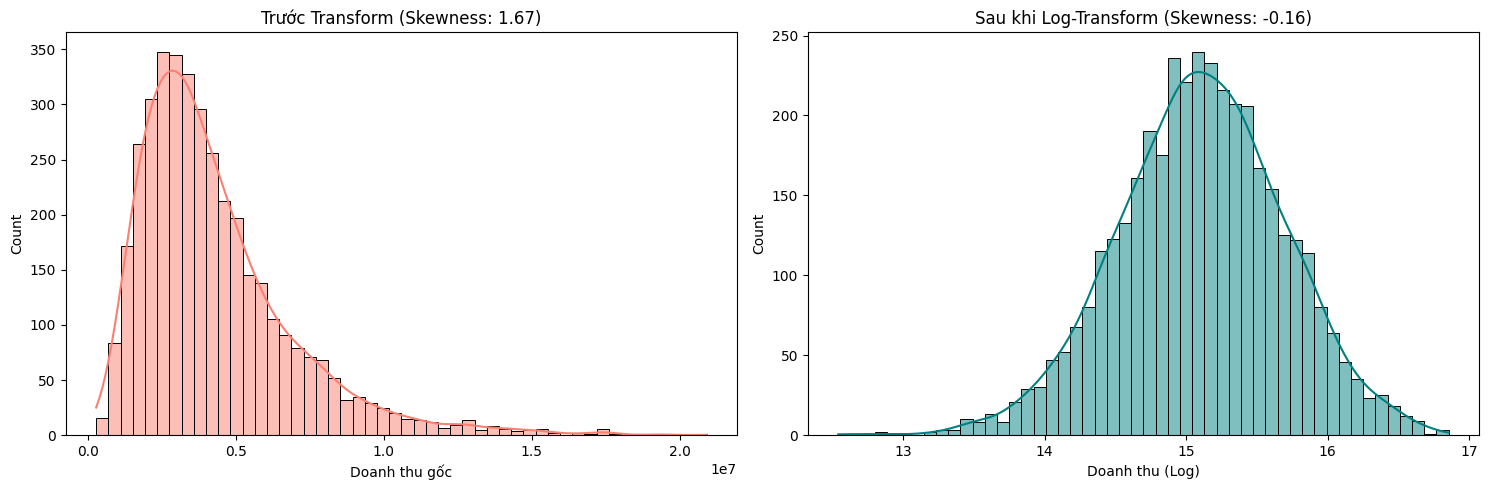

------------------------------------------------------------


In [30]:
# 1. Tính hệ số Skewness
skewness_score = sales['Revenue'].skew()
print(f"-> Hệ số lệch (Skewness) của Revenue: {skewness_score:.2f}")

# 2. Vẽ biểu đồ kiểm chứng
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Dữ liệu gốc
sns.histplot(sales['Revenue'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Trước Transform (Skewness: {skewness_score:.2f})')
axes[0].set_xlabel('Doanh thu gốc')

# 3. Xử lý skewness
if skewness_score > 1 or skewness_score < -1:
    print("=> Dữ liệu bị lệch nặng (Highly Skewed). Tiến hành áp dụng Log-Transform...")
    sales['Revenue_Log'] = np.log1p(sales['Revenue'])

    # Biểu đồ 2: Sau khi Log Transform
    sns.histplot(sales['Revenue_Log'], bins=50, kde=True, ax=axes[1], color='teal')
    axes[1].set_title(f"Sau khi Log-Transform (Skewness: {sales['Revenue_Log'].skew():.2f})")
    axes[1].set_xlabel('Doanh thu (Log)')
else:
    print("=> Dữ liệu phân phối khá chuẩn. Bỏ qua bước Transform!")
    axes[1].text(0.5, 0.5, 'Không cần Transform', ha='center', va='center', fontsize=15)
    axes[1].axis('off') # Ẩn biểu đồ 2 nếu không cần thiết

plt.tight_layout()
plt.show()
print("-" * 60)

## **2.2. Chia tập trainset, cross-validation & testset**

In [31]:
from sklearn.model_selection import TimeSeriesSplit

print("\n[INFO] DATA SPLITTING & TARGET TRANSFORMATION")
print("-" * 60)

# Đảm bảo dữ liệu đã được sắp xếp chuẩn theo thời gian
sales = sales.sort_values('Date').reset_index(drop=True)

# CẮT HOLD-OUT TEST SET
# Tính mốc 80%
split_idx = int(len(sales) * 0.8)

# Chia Train và Test
train_df = sales.iloc[:split_idx].copy()
test_df = sales.iloc[split_idx:].copy()

print(f"-> Tổng số dòng: {len(sales)}")
print(f"-> Tập Train (80% đầu): {len(train_df)} dòng (từ {train_df['Date'].min().date()} đến {train_df['Date'].max().date()})")
print(f"-> Tập Test (20% cuối): {len(test_df)} dòng (từ {test_df['Date'].min().date()} đến {test_df['Date'].max().date()})")

# THIẾT LẬP TIME-SERIES CROSS-VALIDATION (Cho tập Train)
# Khai báo TimeSeriesSplit với 4 Folds
tscv = TimeSeriesSplit(n_splits=4)

print("\n-> Cấu trúc Expanding Window (Trên tập Train):")
fold = 1
for train_index, val_index in tscv.split(train_df):
    train_dates = train_df.iloc[train_index]['Date']
    val_dates = train_df.iloc[val_index]['Date']

    print(f"   Fold {fold}: Train từ {train_dates.min().date()} -> {train_dates.max().date()} | "
          f"Validate từ {val_dates.min().date()} -> {val_dates.max().date()}")
    fold += 1

print("-" * 60)


[INFO] DATA SPLITTING & TARGET TRANSFORMATION
------------------------------------------------------------
-> Tổng số dòng: 3833
-> Tập Train (80% đầu): 3066 dòng (từ 2012-07-04 đến 2020-11-24)
-> Tập Test (20% cuối): 767 dòng (từ 2020-11-25 đến 2022-12-31)

-> Cấu trúc Expanding Window (Trên tập Train):
   Fold 1: Train từ 2012-07-04 -> 2014-03-09 | Validate từ 2014-03-10 -> 2015-11-12
   Fold 2: Train từ 2012-07-04 -> 2015-11-12 | Validate từ 2015-11-13 -> 2017-07-17
   Fold 3: Train từ 2012-07-04 -> 2017-07-17 | Validate từ 2017-07-18 -> 2019-03-22
   Fold 4: Train từ 2012-07-04 -> 2019-03-22 | Validate từ 2019-03-23 -> 2020-11-24
------------------------------------------------------------


## **2.3. Kiểm tra & xử lý đa cộng tuyến**


[INFO] KIỂM TRA ĐA CỘNG TUYẾN (CORRELATION HEATMAP)
------------------------------------------------------------


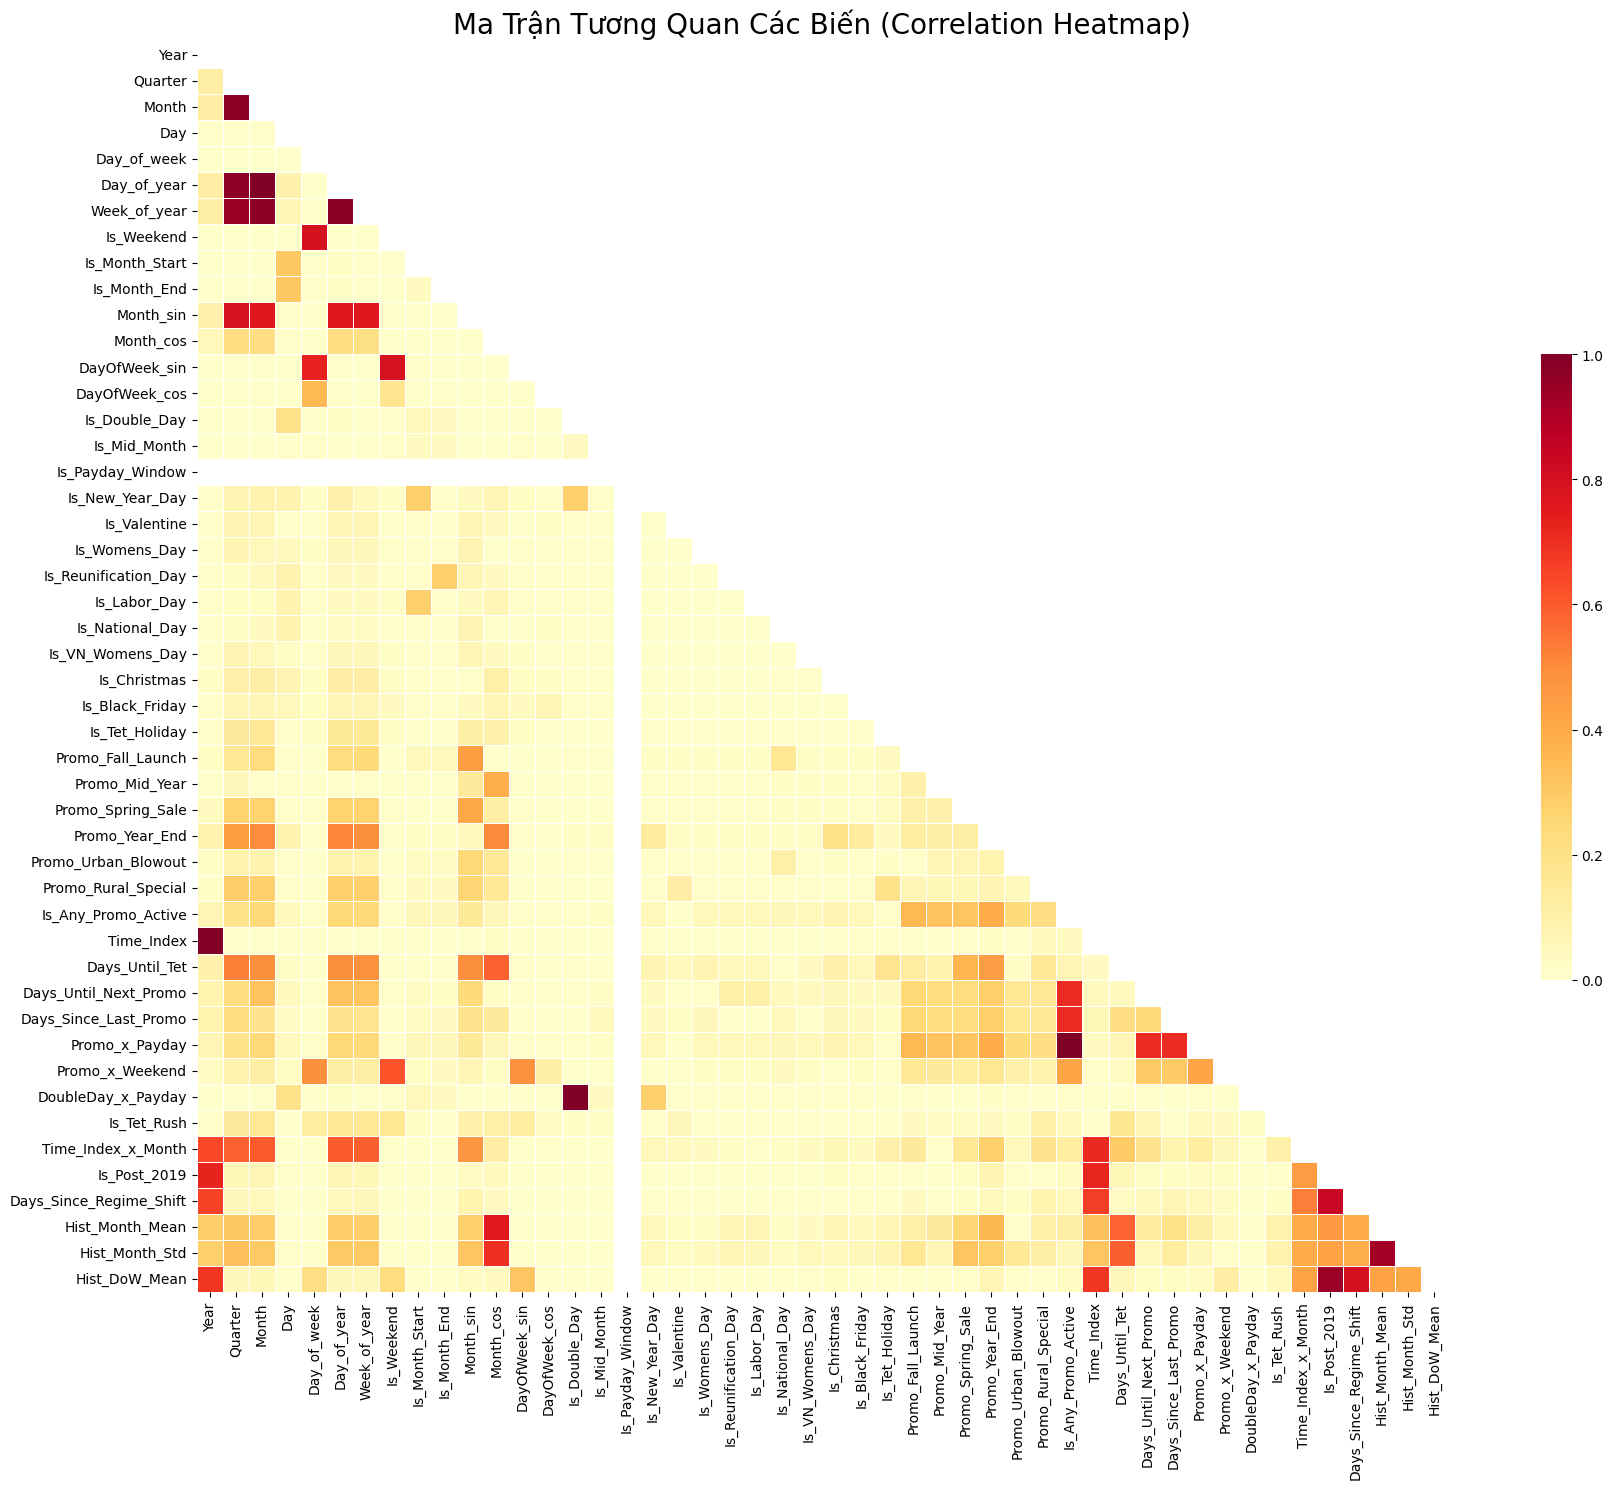


-> Các cặp biến có độ tương quan rất cao (> 0.8):
   - [Quarter] và [Month] : 0.971
   - [Quarter] và [Day_of_year] : 0.968
   - [Month] và [Day_of_year] : 0.996
   - [Quarter] và [Week_of_year] : 0.948
   - [Month] và [Week_of_year] : 0.973
   - [Day_of_year] và [Week_of_year] : 0.974
   - [Year] và [Time_Index] : 0.993
   - [Is_Any_Promo_Active] và [Promo_x_Payday] : 1.000
   - [Is_Double_Day] và [DoubleDay_x_Payday] : 1.000
   - [Is_Post_2019] và [Days_Since_Regime_Shift] : 0.836
   - [Hist_Month_Mean] và [Hist_Month_Std] : 0.923
   - [Is_Post_2019] và [Hist_DoW_Mean] : 0.944

=> Đã tự động loại bỏ 9 biến trùng lặp thông tin.
=> Số lượng biến còn lại sẵn sàng cho Bước 4 (Features Selection): 39
------------------------------------------------------------


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n[INFO] KIỂM TRA ĐA CỘNG TUYẾN (CORRELATION HEATMAP)")
print("-" * 60)

# 1. Khởi tạo dữ liệu sạch cho quá trình train (Tách biến mục tiêu)
ignore_cols = ['Date', 'Revenue', 'Revenue_Log']
features = [col for col in train_df.columns if col not in ignore_cols]

X_train_clean = train_df[features].copy()

# 2. Tính Ma trận tương quan (Chỉ xét độ lớn, nên dùng trị tuyệt đối)
corr_matrix = X_train_clean.corr().abs()

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(20, 15)) # Kích thước lớn vì có nhiều biến
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='YlOrRd', vmax=1.0, vmin=0.0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Ma Trận Tương Quan Các Biến (Correlation Heatmap)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Liệt kê các cặp tương quan > 0.8
print("\n-> Các cặp biến có độ tương quan rất cao (> 0.8):")
threshold = 0.8
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > threshold:
            high_corr_pairs.append((row, col, upper_tri.loc[row, col]))

# In kết quả
if not high_corr_pairs:
    print("Không có cặp biến nào bị đa cộng tuyến nghiêm trọng")
else:
    for pair in high_corr_pairs:
        print(f"   - [{pair[0]}] và [{pair[1]}] : {pair[2]:.3f}")

# 5. Tự động loại bỏ (Drop) một trong hai biến của các cặp trùng lặp
to_drop_collinear = [col for _, col, _ in high_corr_pairs]
X_train_clean = X_train_clean.drop(columns=to_drop_collinear)

print(f"\n=> Đã tự động loại bỏ {len(set(to_drop_collinear))} biến trùng lặp thông tin.")
print(f"=> Số lượng biến còn lại sẵn sàng cho Bước 4 (Features Selection): {X_train_clean.shape[1]}")
print("-" * 60)

## **2.4. Feature selection**


[INFO] ENSEMBLE FEATURE SELECTION
------------------------------------------------------------
1. Đang chạy Mutual Information...
2. Đang chạy Random Forest Importance...
3. Đang chạy RFE...

-> Đang tổng hợp kết quả...

=> Đã chốt danh sách 30 biến xuất sắc nhất (Đạt >= 2 phiếu).


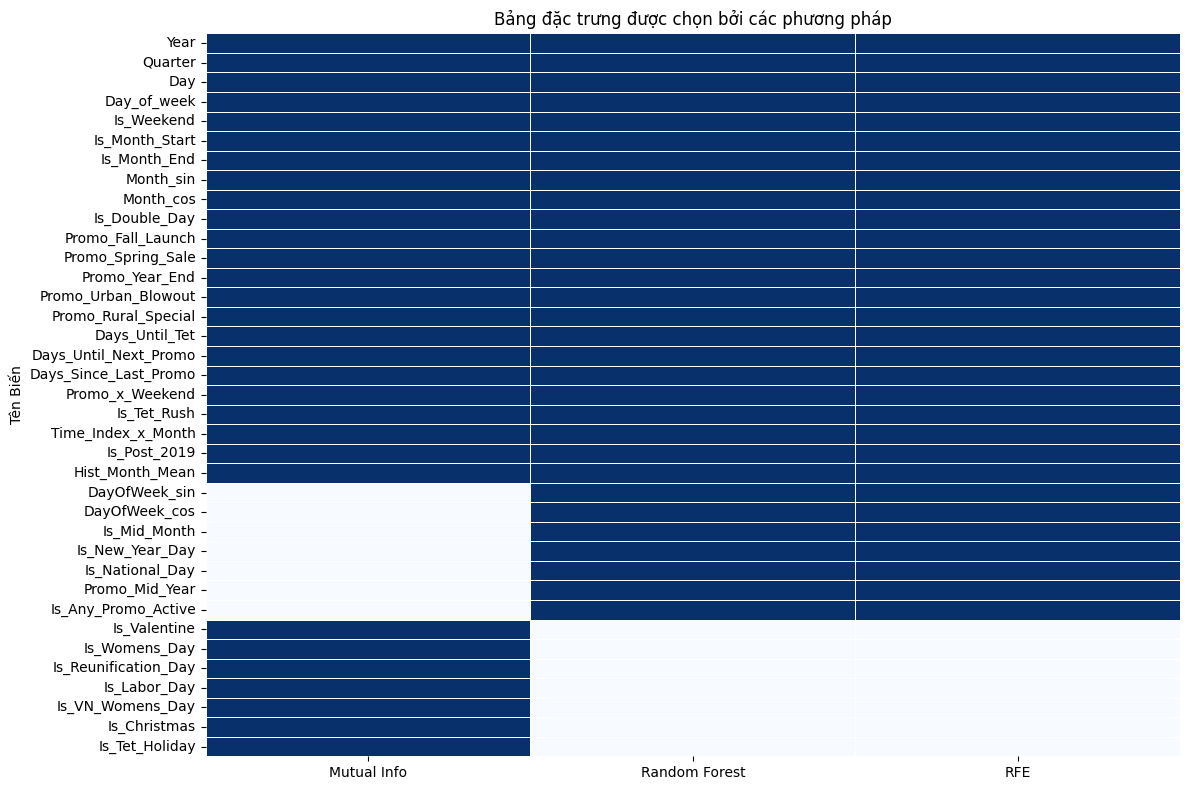

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, RFE

print("\n[INFO] ENSEMBLE FEATURE SELECTION")
print("-" * 60)

# =========================================================
# KHỞI TẠO X_train_clean VÀ y_train TỪ train_df
# =========================================================
ignore_cols = ['Date', 'Revenue', 'Revenue_Log']
features = [col for col in train_df.columns if col not in ignore_cols]

y_train = train_df['Revenue_Log']
# =========================================================

# Số lượng features tối đa ta muốn giữ lại
N_FEATURES = 30

# Mảng lưu trữ kết quả "bầu chọn" (1 = được chọn, 0 = không được chọn)
votes = pd.DataFrame({'Feature': X_train_clean.columns})
votes = votes.set_index('Feature')

# ---------------------------------------------------------
# PHƯƠNG PHÁP 1: MUTUAL INFORMATION (Filter Method)
# ---------------------------------------------------------
print("1. Đang chạy Mutual Information...")
mi_scores = mutual_info_regression(X_train_clean, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_clean.columns)
top_mi_features = mi_series.nlargest(N_FEATURES).index
votes['Vote_MI'] = votes.index.isin(top_mi_features).astype(int)

# ---------------------------------------------------------
# PHƯƠNG PHÁP 2: RANDOM FOREST IMPORTANCE (Embedded Method)
# ---------------------------------------------------------
print("2. Đang chạy Random Forest Importance...")
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_clean, y_train)
rf_series = pd.Series(rf.feature_importances_, index=X_train_clean.columns)
top_rf_features = rf_series.nlargest(N_FEATURES).index
votes['Vote_RF'] = votes.index.isin(top_rf_features).astype(int)

# ---------------------------------------------------------
# PHƯƠNG PHÁP 3: RFE - RECURSIVE FEATURE ELIMINATION (Wrapper Method)
# ---------------------------------------------------------
print("3. Đang chạy RFE...")
rfe = RFE(estimator=rf, n_features_to_select=N_FEATURES, step=5)
rfe.fit(X_train_clean, y_train)
top_rfe_features = X_train_clean.columns[rfe.support_]
votes['Vote_RFE'] = votes.index.isin(top_rfe_features).astype(int)

# ---------------------------------------------------------
# TỔNG HỢP KẾT QUẢ
# ---------------------------------------------------------
print("\n-> Đang tổng hợp kết quả...")
votes['Total_Votes'] = votes['Vote_MI'] + votes['Vote_RF'] + votes['Vote_RFE']

# CHỌN LỌC: Chỉ lấy những biến có ÍT NHẤT 2 PHIẾU
final_features = votes[votes['Total_Votes'] >= 2].index.tolist()

print(f"\n=> Đã chốt danh sách {len(final_features)} biến xuất sắc nhất (Đạt >= 2 phiếu).")

# Vẽ biểu đồ trực quan
plt.figure(figsize=(12, 8))
selected_votes = votes[votes['Total_Votes'] > 0].sort_values(by=['Total_Votes', 'Vote_RF'], ascending=[False, False])
sns.heatmap(selected_votes[['Vote_MI', 'Vote_RF', 'Vote_RFE']], cmap='Blues', cbar=False, linewidths=0.5)
plt.title('Bảng đặc trưng được chọn bởi các phương pháp')
plt.ylabel('Tên Biến')
plt.xticks([0.5, 1.5, 2.5], ['Mutual Info', 'Random Forest', 'RFE'])
plt.tight_layout()
plt.show()

# Cập nhật lại tập X_train và X_test với các biến đã được chọn
X_train_final = X_train_clean[final_features]
X_test_final = test_df[final_features]
y_test = test_df['Revenue_Log']

# **III - XÂY DỰNG MÔ HÌNH**
## **3.1. Mô hình với bộ tham số mặc định**


[INFO] GIAI ĐOẠN 1: DEFAULT PARAMETERS
------------------------------------------------------------
-> Đang tiến hành huấn luyện và đo lường 3 chỉ số...
   Đang chạy Fold 1...
   Đang chạy Fold 2...
   Đang chạy Fold 3...
   Đang chạy Fold 4...

[KẾT QUẢ TỔNG HỢP TRUNG BÌNH (DEFAULT PARAMETERS)]
 RANDOM FOREST:
   - MAE  : 1,038,211 (Càng thấp càng tốt)
   - RMSE : 1,464,235 (Càng thấp càng tốt)
   - R2   : 0.6603 (Gần 1 là xuất sắc)

 XGBOOST:
   - MAE  : 1,111,699 (Càng thấp càng tốt)
   - RMSE : 1,551,378 (Càng thấp càng tốt)
   - R2   : 0.6239 (Gần 1 là xuất sắc)

 LIGHTGBM:
   - MAE  : 1,052,472 (Càng thấp càng tốt)
   - RMSE : 1,455,947 (Càng thấp càng tốt)
   - R2   : 0.6664 (Gần 1 là xuất sắc)



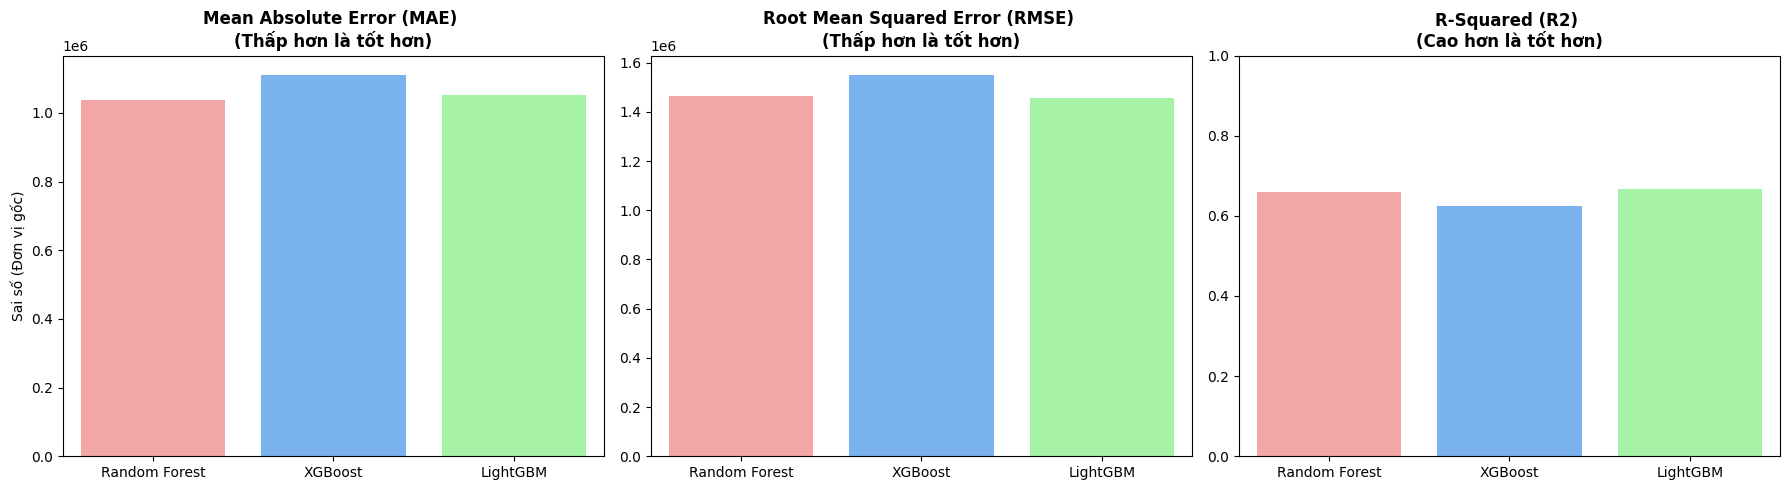

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("\n[INFO] GIAI ĐOẠN 1: DEFAULT PARAMETERS")
print("-" * 60)

models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:absoluteerror'),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, objective='mae')
}

# Khởi tạo từ điển lưu trữ cả 3 chỉ số cho từng mô hình
cv_results = {name: {'MAE': [], 'RMSE': [], 'R2': []} for name in models.keys()}

# Time-Series Cross Validation
print("-> Đang tiến hành huấn luyện và đo lường 3 chỉ số...")
fold = 1
for train_index, val_index in tscv.split(X_train_final):
    print(f"   Đang chạy Fold {fold}...")

    X_tr, X_val = X_train_final.iloc[train_index], X_train_final.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    for name, model in models.items():
        # Huấn luyện
        model.fit(X_tr, y_tr)
        preds_log = model.predict(X_val)

        # ĐẢO NGƯỢC LOG (Về đơn vị tiền thực tế) để đánh giá chính xác
        preds_real = np.expm1(preds_log)
        actuals_real = np.expm1(y_val)

        # Tính toán 3 chỉ số
        mae = mean_absolute_error(actuals_real, preds_real)
        rmse = np.sqrt(mean_squared_error(actuals_real, preds_real))
        r2 = r2_score(actuals_real, preds_real)

        cv_results[name]['MAE'].append(mae)
        cv_results[name]['RMSE'].append(rmse)
        cv_results[name]['R2'].append(r2)

    fold += 1

# TỔNG HỢP KẾT QUẢ TRUNG BÌNH CÁC FOLDS
print("\n[KẾT QUẢ TỔNG HỢP TRUNG BÌNH (DEFAULT PARAMETERS)]")
print("=" * 60)
avg_results = {name: {} for name in models.keys()}

for name in models.keys():
    avg_results[name]['MAE'] = np.mean(cv_results[name]['MAE'])
    avg_results[name]['RMSE'] = np.mean(cv_results[name]['RMSE'])
    avg_results[name]['R2'] = np.mean(cv_results[name]['R2'])

    print(f" {name.upper()}:")
    print(f"   - MAE  : {avg_results[name]['MAE']:,.0f} (Càng thấp càng tốt)")
    print(f"   - RMSE : {avg_results[name]['RMSE']:,.0f} (Càng thấp càng tốt)")
    print(f"   - R2   : {avg_results[name]['R2']:.4f} (Gần 1 là xuất sắc)\n")

# 4. TRỰC QUAN HÓA KẾT QUẢ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(models.keys())
colors = ['#FF9999', '#66B2FF', '#99FF99']

# Biểu đồ 1: MAE
sns.barplot(x=model_names, y=[avg_results[m]['MAE'] for m in model_names], ax=axes[0], palette=colors)
axes[0].set_title('Mean Absolute Error (MAE) \n(Thấp hơn là tốt hơn)', fontweight='bold')
axes[0].set_ylabel('Sai số (Đơn vị gốc)')

# Biểu đồ 2: RMSE
sns.barplot(x=model_names, y=[avg_results[m]['RMSE'] for m in model_names], ax=axes[1], palette=colors)
axes[1].set_title('Root Mean Squared Error (RMSE) \n(Thấp hơn là tốt hơn)', fontweight='bold')

# Biểu đồ 3: R2 Score
sns.barplot(x=model_names, y=[avg_results[m]['R2'] for m in model_names], ax=axes[2], palette=colors)
axes[2].set_title('R-Squared (R2) \n(Cao hơn là tốt hơn)', fontweight='bold')
axes[2].set_ylim(0, 1.0) # Ép khung R2 từ 0 đến 1 để dễ nhìn

plt.tight_layout()
plt.show()

## **3.2. Hyperparameter tuning**

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("\n[INFO] RANDOM SEARCH TUNING & RETRAIN CHO 3 MÔ HÌNH")
print("-" * 60)

# ==============================================================================
# 1. HYPERPARAMETER GRID
# ==============================================================================
xgb_param_grid = {
    'n_estimators': [100, 300, 500, 700], # Số lượng cây
    'max_depth': [3, 5, 7],               # Độ sâu của cây (tránh overfitting)
    'learning_rate': [0.01, 0.05, 0.1],   # Tốc độ học
    'subsample': [0.7, 0.8, 0.9, 1.0],    # Tỷ lệ lấy mẫu dữ liệu cho mỗi cây
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0] # Tỷ lệ lấy mẫu features
}

lgbm_param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'num_leaves': [31, 63, 127],          # Số lượng lá
    'max_depth': [-1, 5, 7],              # -1 nghĩa là không giới hạn
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Lưới tham số bổ sung cho Random Forest
rf_param_grid = {
    'n_estimators': [100, 300, 500],      # Số lượng cây
    'max_depth': [10, 20, 30, None],      # Độ sâu (None là để cây mọc tự do)
    'min_samples_split': [2, 5, 10],      # Số mẫu tối thiểu để chia nhánh
    'min_samples_leaf': [1, 2, 4],        # Số mẫu tối thiểu ở node lá
    'max_features': ['sqrt', 'log2', 1.0] # Số lượng features cân nhắc ở mỗi nhánh
}

# ==============================================================================
# 2. KHỞI CHẠY RANDOM SEARCH
# ==============================================================================

print("-> 1. Đang Tuning XGBoost...")
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, objective='reg:absoluteerror'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error', # Vẫn đánh giá chéo bằng RMSE
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)
xgb_random.fit(X_train_final, y_train)
print(f"   [XGBoost Best Params]: {xgb_random.best_params_}")

print("\n-> 2. Đang Tuning LightGBM...")
lgbm_random = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, objective='mae'),
    param_distributions=lgbm_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)
lgbm_random.fit(X_train_final, y_train)
print(f"   [LightGBM Best Params]: {lgbm_random.best_params_}")

print("\n-> 3. Đang Tuning Random Forest...")
rf_random = RandomizedSearchCV(
    # Lưu ý: Không dùng criterion='absolute_error' cho RF vì thuật toán này sẽ chạy CỰC KỲ CHẬM.
    # Giữ nguyên mặc định (squared_error) là giải pháp an toàn nhất để không bị treo máy.
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)
rf_random.fit(X_train_final, y_train)
print(f"   [Random Forest Best Params]: {rf_random.best_params_}")

# ==============================================================================
# 3. TRÍCH XUẤT
# ==============================================================================
best_xgb = xgb_random.best_estimator_
best_lgbm = lgbm_random.best_estimator_
best_rf = rf_random.best_estimator_


[INFO] RANDOM SEARCH TUNING & RETRAIN CHO 3 MÔ HÌNH
------------------------------------------------------------
-> 1. Đang Tuning XGBoost...
Fitting 4 folds for each of 30 candidates, totalling 120 fits
   [XGBoost Best Params]: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

-> 2. Đang Tuning LightGBM...
Fitting 4 folds for each of 30 candidates, totalling 120 fits
   [LightGBM Best Params]: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

-> 3. Đang Tuning Random Forest...
Fitting 4 folds for each of 30 candidates, totalling 120 fits
   [Random Forest Best Params]: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("\n[INFO] ENSEMBLE & KIỂM ĐỊNH TRÊN TẬP TEST (TÌM TỶ LỆ CHO 3 MÔ HÌNH)")
print("-" * 60)

# ==============================================================================
# 1. TRÍCH XUẤT DỰ BÁO TỪ 3 MÔ HÌNH
# ==============================================================================
print("-> Đang trích xuất dự báo từ XGBoost (Tuned)...")
xgb_preds_log = best_xgb.predict(X_test_final)

print("-> Đang trích xuất dự báo từ LightGBM (Tuned)...")
lgbm_preds_log = best_lgbm.predict(X_test_final)

print("-> Đang trích xuất dự báo từ Random Forest (Tuned)...")
rf_preds_log = best_rf.predict(X_test_final)

# ĐẢO NGƯỢC LOG (Biến Logarit trở lại thành Tiền thật)
xgb_preds_real = np.expm1(xgb_preds_log)
lgbm_preds_real = np.expm1(lgbm_preds_log)
rf_preds_real = np.expm1(rf_preds_log)
actuals_real = np.expm1(y_test)

# ==============================================================================
# 2. ENSEMBLE
# ==============================================================================
print("\n[INFO] ĐANG CHẠY TỔ HỢP ENSEMBLE...")
results = {}

# --- Tổ hợp 1: LightGBM + XGBoost ---
best_r2_lx, best_w_lx = -np.inf, (0, 0)
for i in range(101):
    w_l = i / 100.0
    w_x = 1.0 - w_l
    preds = (w_l * lgbm_preds_real) + (w_x * xgb_preds_real)
    r2 = r2_score(actuals_real, preds)
    if r2 > best_r2_lx: best_r2_lx, best_w_lx = r2, (w_l, w_x)
results['L_X'] = {'name': 'LightGBM + XGBoost', 'r2': best_r2_lx, 'preds': (best_w_lx[0]*lgbm_preds_real + best_w_lx[1]*xgb_preds_real), 'msg': f"LGBM: {best_w_lx[0]*100:.0f}%, XGB: {best_w_lx[1]*100:.0f}%"}

# --- Tổ hợp 2: LightGBM + Random Forest ---
best_r2_lr, best_w_lr = -np.inf, (0, 0)
for i in range(101):
    w_l = i / 100.0
    w_r = 1.0 - w_l
    preds = (w_l * lgbm_preds_real) + (w_r * rf_preds_real)
    r2 = r2_score(actuals_real, preds)
    if r2 > best_r2_lr: best_r2_lr, best_w_lr = r2, (w_l, w_r)
results['L_R'] = {'name': 'LightGBM + Random Forest', 'r2': best_r2_lr, 'preds': (best_w_lr[0]*lgbm_preds_real + best_w_lr[1]*rf_preds_real), 'msg': f"LGBM: {best_w_lr[0]*100:.0f}%, RF: {best_w_lr[1]*100:.0f}%"}

# --- Tổ hợp 3: XGBoost + Random Forest ---
best_r2_xr, best_w_xr = -np.inf, (0, 0)
for i in range(101):
    w_x = i / 100.0
    w_r = 1.0 - w_x
    preds = (w_x * xgb_preds_real) + (w_r * rf_preds_real)
    r2 = r2_score(actuals_real, preds)
    if r2 > best_r2_xr: best_r2_xr, best_w_xr = r2, (w_x, w_r)
results['X_R'] = {'name': 'XGBoost + Random Forest', 'r2': best_r2_xr, 'preds': (best_w_xr[0]*xgb_preds_real + best_w_xr[1]*rf_preds_real), 'msg': f"XGB: {best_w_xr[0]*100:.0f}%, RF: {best_w_xr[1]*100:.0f}%"}

# --- Tổ hợp 4: Cả 3 mô hình ---
best_r2_all, best_w_all = -np.inf, (0, 0, 0)
for i in range(101):
    w_l = i / 100.0
    for j in range(101 - i):
        w_x = j / 100.0
        w_r = 1.0 - w_l - w_x
        preds = (w_l * lgbm_preds_real) + (w_x * xgb_preds_real) + (w_r * rf_preds_real)
        r2 = r2_score(actuals_real, preds)
        if r2 > best_r2_all: best_r2_all, best_w_all = r2, (w_l, w_x, w_r)
results['ALL'] = {'name': 'LightGBM + XGBoost + Random Forest', 'r2': best_r2_all, 'preds': (best_w_all[0]*lgbm_preds_real + best_w_all[1]*xgb_preds_real + best_w_all[2]*rf_preds_real), 'msg': f"LGBM: {best_w_all[0]*100:.0f}%, XGB: {best_w_all[1]*100:.0f}%, RF: {best_w_all[2]*100:.0f}%"}

# ==============================================================================
# 3. SO SÁNH
# ==============================================================================
print("-" * 60)
print(f"1. [LGBM + XGB]      -> R2: {results['L_X']['r2']:.6f} ({results['L_X']['msg']})")
print(f"2. [LGBM + RF]       -> R2: {results['L_R']['r2']:.6f} ({results['L_R']['msg']})")
print(f"3. [XGB + RF]        -> R2: {results['X_R']['r2']:.6f} ({results['X_R']['msg']})")
print(f"4. [CẢ 3 MÔ HÌNH]    -> R2: {results['ALL']['r2']:.6f} ({results['ALL']['msg']})")
print("-" * 60)

# Lấy chiến thuật có R2 cao nhất
best_strategy_key = max(results, key=lambda k: results[k]['r2'])
best_strategy = results[best_strategy_key]
ensemble_preds_real = best_strategy['preds']

print(f"\n🏆 [CHIẾN THUẬT CHIẾN THẮNG: {best_strategy['name'].upper()}]")
print(f"   Áp dụng tỷ lệ: {best_strategy['msg']}")

# ==============================================================================
# 4. KẾT QUẢ ĐO LƯỜNG CUỐI CÙNG
# ==============================================================================
ensemble_mae = mean_absolute_error(actuals_real, ensemble_preds_real)
ensemble_rmse = np.sqrt(mean_squared_error(actuals_real, ensemble_preds_real))
ensemble_r2 = r2_score(actuals_real, ensemble_preds_real)

print("\n[KẾT QUẢ CUỐI CÙNG: MÔ HÌNH ENSEMBLE (TUNED)]")
print("=" * 60)
print(f" - MAE  : {ensemble_mae:,.0f} (Lệch khoảng {ensemble_mae/1000000:.2f} triệu VNĐ/ngày)")
print(f" - RMSE : {ensemble_rmse:,.0f}")
print(f" - R2   : {ensemble_r2:.6f}")
print("-" * 60)


[INFO] ENSEMBLE & KIỂM ĐỊNH TRÊN TẬP TEST (TÌM TỶ LỆ CHO 3 MÔ HÌNH)
------------------------------------------------------------
-> Đang trích xuất dự báo từ XGBoost (Tuned)...
-> Đang trích xuất dự báo từ LightGBM (Tuned)...
-> Đang trích xuất dự báo từ Random Forest (Tuned)...

[INFO] ĐANG CHẠY TỔ HỢP ENSEMBLE...
------------------------------------------------------------
1. [LGBM + XGB]      -> R2: 0.771599 (LGBM: 83%, XGB: 17%)
2. [LGBM + RF]       -> R2: 0.770917 (LGBM: 100%, RF: 0%)
3. [XGB + RF]        -> R2: 0.754411 (XGB: 100%, RF: 0%)
4. [CẢ 3 MÔ HÌNH]    -> R2: 0.771599 (LGBM: 83%, XGB: 17%, RF: 0%)
------------------------------------------------------------

🏆 [CHIẾN THUẬT CHIẾN THẮNG: LIGHTGBM + XGBOOST]
   Áp dụng tỷ lệ: LGBM: 83%, XGB: 17%

[KẾT QUẢ CUỐI CÙNG: MÔ HÌNH ENSEMBLE (TUNED)]
 - MAE  : 573,946 (Lệch khoảng 0.57 triệu VNĐ/ngày)
 - RMSE : 797,701
 - R2   : 0.771599
------------------------------------------------------------


## **3.3. Giải thích mô hình**


[INFO] GIẢI MÃ MÔ HÌNH BẰNG SHAP VALUES
------------------------------------------------------------


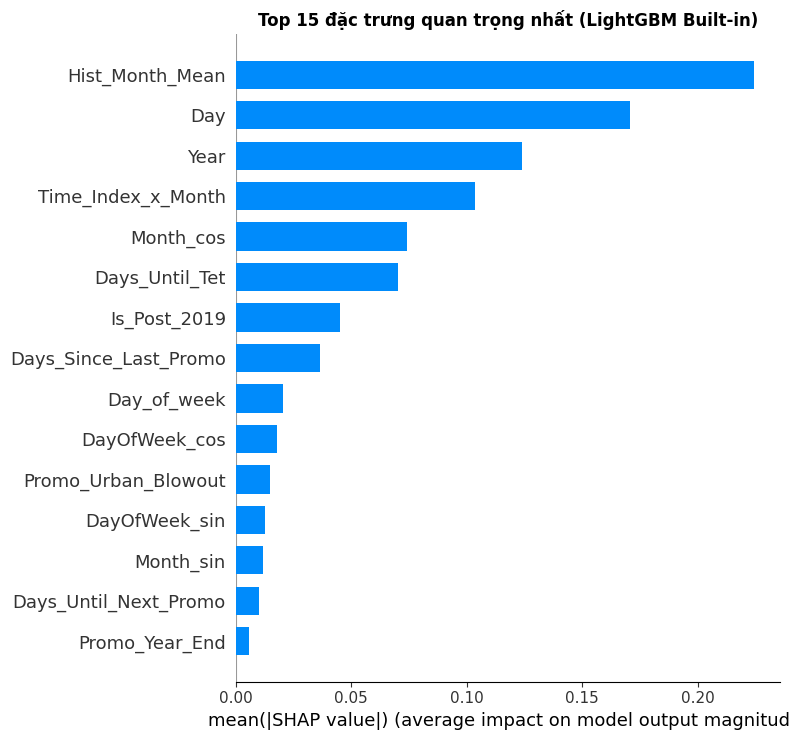

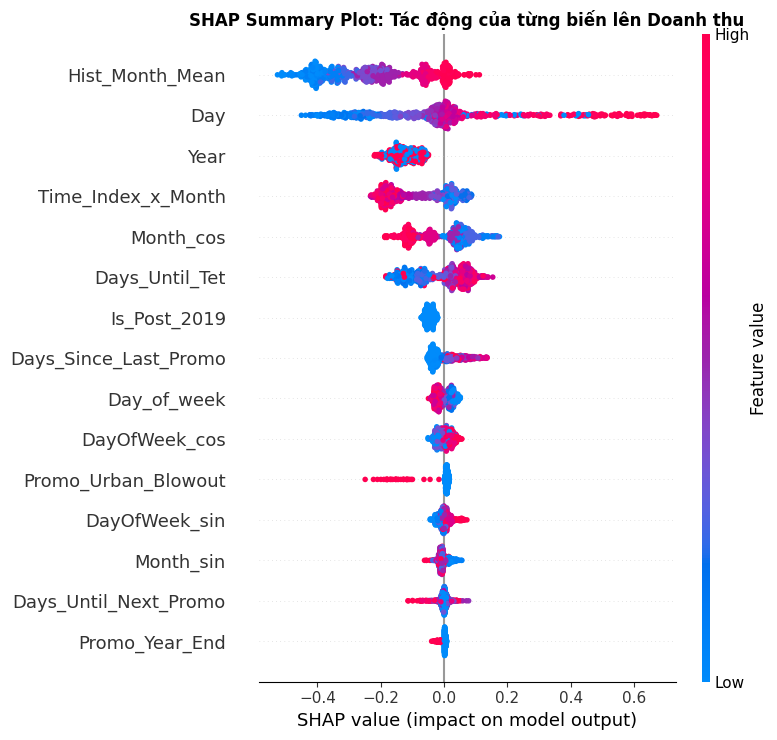

In [37]:
!pip install shap

import shap
import matplotlib.pyplot as plt

print("\n[INFO] GIẢI MÃ MÔ HÌNH BẰNG SHAP VALUES")
print("-" * 60)

# 1. Khởi tạo SHAP Explainer cho LightGBM
explainer = shap.TreeExplainer(best_lgbm)

# Tính toán SHAP values trên tập Test (Để xem nó dự báo tương lai dựa vào đâu)
shap_values = explainer.shap_values(X_test_final)

# 2. VẼ BIỂU ĐỒ FEATURE IMPORTANCE (Mức độ quan trọng tổng thể)
plt.figure(figsize=(3, 5))
plt.title("Top 15 đặc trưng quan trọng nhất (LightGBM Built-in)", fontweight='bold')
shap.summary_plot(shap_values, X_test_final, plot_type="bar", max_display=15)
plt.show()

# 3. VẼ BIỂU ĐỒ SHAP SUMMARY PLOT (Phân tích chi tiết Tác động & Chiều hướng)
plt.figure(figsize=(3, 5))
plt.title("SHAP Summary Plot: Tác động của từng biến lên Doanh thu", fontweight='bold')
shap.summary_plot(shap_values, X_test_final, max_display=15)
plt.show()

# **IV - ÁP DỤNG MÔ HÌNH ĐỂ DỰ BÁO DOANH THU TỪ 01/01/2023-01/07/2024**

In [38]:
import pandas as pd
import numpy as np
from google.colab import files

# ==============================================================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==============================================================================
# Lấy đúng danh sách cột đã dùng để train mô hình (loại bỏ Date, Revenue, COGS)
features_list = X_train_final.columns.tolist()
X_submission = submission_features[features_list]

In [39]:
print(f"-> Đã trích xuất thành công {len(features_list)} features khớp 100% với tập Train.")

# ==============================================================================
# 2. CHẠY DỰ BÁO TRÊN 3 MÔ HÌNH ĐÃ TINH CHỈNH
# ==============================================================================
xgb_sub_log = best_xgb.predict(X_submission)
lgbm_sub_log = best_lgbm.predict(X_submission)
rf_sub_log = best_rf.predict(X_submission)

# Đảo ngược Log về tiền thực
xgb_sub_real = np.expm1(xgb_sub_log)
lgbm_sub_real = np.expm1(lgbm_sub_log)
rf_sub_real = np.expm1(rf_sub_log)

# ==============================================================================
# 3. TỰ ĐỘNG LẤY TỶ LỆ CỦA TỔ HỢP TỐT NHẤT
# ==============================================================================
# Kéo lại kết quả tỷ lệ vàng từ biến best_strategy_key ở ô code trước
if best_strategy_key == 'L_X':
    w_l, w_x, w_r = best_w_lx[0], best_w_lx[1], 0.0
elif best_strategy_key == 'L_R':
    w_l, w_x, w_r = best_w_lr[0], 0.0, best_w_lr[1]
elif best_strategy_key == 'X_R':
    w_l, w_x, w_r = 0.0, best_w_xr[0], best_w_xr[1]
else:
    w_l, w_x, w_r = best_w_all

print(f"-> Tỷ lệ áp dụng: {w_l*100:.0f}% LightGBM + {w_x*100:.0f}% XGBoost + {w_r*100:.0f}% Random Forest")

# Trộn kết quả dự báo
final_sub_preds = (w_l * lgbm_sub_real) + (w_x * xgb_sub_real) + (w_r * rf_sub_real)

# ==============================================================================
# 4. GHI ĐÈ VÀ XUẤT FILE NỘP BÀI
# ==============================================================================
print("-> Đang đóng gói dữ liệu cuối cùng...")
final_submission = submission_features.copy()

# Ghi đè doanh thu dự báo vào cột Revenue
final_submission['Revenue'] = final_sub_preds

# Cắt số âm (Nguyên tắc an toàn tối thượng để hệ thống không chấm lỗi)
final_submission['Revenue'] = final_submission['Revenue'].clip(lower=0)

# Định dạng chuẩn: Chỉ lấy đúng 3 cột và format lại Date
final_submission = final_submission[['Date', 'Revenue', 'COGS']]
final_submission['Date'] = final_submission['Date'].dt.strftime('%Y-%m-%d')

# Xuất file CSV
output_filename = 'My_Submission.csv'
final_submission.to_csv(output_filename, index=False)

-> Đã trích xuất thành công 30 features khớp 100% với tập Train.
-> Tỷ lệ áp dụng: 83% LightGBM + 17% XGBoost + 0% Random Forest
-> Đang đóng gói dữ liệu cuối cùng...


In [40]:
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>